<b>1.</b> Create a program that will read in all the images from a folder and use them to get the calibration 
parameters. Calibrate your camera using a minimum of three data sets. Compare and contrast the 
results. Do they make sense. One of the data sets should have at least 25 images. Calibrate the 
camera using 2, 5, 10, 15 and 25 images. Compare the results. What do they tell us?

In [1]:
import os
import random

import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from src.calibration.calibrate_camera import CameraCalibrator
from src.calibration.chessboard_detector import ChessboardDetector
from src.io.image_reader import ImageReader
from src.processing.image_filtering import ImageFiltering
from src.processing.image_thresholding import Thresholder
from src.processing.morphological_filters import MorphologicalFilter

CALIBRATION_PATH = "images/calibration_set"
FILTERED_PATH = "images/filtered_set"
CALIBRATION_DIR = "callibration_matrices"
CHESSBOARD_SIZE = (10, 7)
SQUARE_SIZE_MM = 23.5

os.makedirs(CALIBRATION_DIR, exist_ok=True)


/home/megrad/Documents/GitHub/ME566/Homework/one/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Keep only calibration images in which the full chessboard is detected.
if not os.path.exists(FILTERED_PATH) or not os.listdir(FILTERED_PATH):
    os.makedirs(FILTERED_PATH, exist_ok=True)
    detector = ChessboardDetector(chessboard_size=CHESSBOARD_SIZE)
    source_images = ImageReader(CALIBRATION_PATH).images

    valid_count = 0
    for image in tqdm(source_images, desc="Filtering calibration images"):
        detected, _ = detector.detect_chessboard(image)
        if detected:
            cv2.imwrite(os.path.join(FILTERED_PATH, f"image_{valid_count}.jpg"), image)
            valid_count += 1
    print(f"Saved {valid_count} images with detected chessboards.")

filtered_dataset = list(ImageReader(FILTERED_PATH).images)
print(f"Using {len(filtered_dataset)} usable calibration images.")


Using 410 usable calibration images.


In [3]:
# Use a fixed seed so each run compares the same image subsets.
rng = random.Random(566)
sample_sizes = [2, 5, 10, 15, 25]
calibration_sets = {size: rng.sample(filtered_dataset, size) for size in sample_sizes}
calibration_sets["all"] = filtered_dataset


In [4]:
def run_calibration(label, images):
    calibrator = CameraCalibrator(
        images=images,
        chessboard_size=CHESSBOARD_SIZE,
        square_size=SQUARE_SIZE_MM,
    )
    values = calibrator.calibrate()
    reprojection = calibrator.reprojection_error()
    file_label = values["successful_images"] if label == "all" else label
    path = os.path.join(CALIBRATION_DIR, f"jordansS23FE_{file_label}_image_cal.npz")
    calibrator.save_calibration(path)

    return {
        "set size": label,
        "usable images": values["successful_images"],
        "RMS error": values["rms_error"],
        "mean reprojection error": reprojection["mean"],
        "saved to": path,
    }

calibration_results = [
    run_calibration(label, images)
    for label, images in tqdm(
        calibration_sets.items(),
        desc="Running calibrations",
    )
]

for result in calibration_results:
    print(f"\nCalibration set: {result['set size']}")
    print(f"Usable images: {result['usable images']}")
    print(f"RMS error: {result['RMS error']:.4f} pixels")
    print(f"Mean reprojection error: {result['mean reprojection error']:.4f} pixels")
    print(f"Saved calibration: {result['saved to']}")


Running calibrations: 100%|██████████| 6/6 [00:10<00:00,  1.73s/it]


Calibration set: 2
Usable images: 2
RMS error: 0.3167 pixels
Mean reprojection error: 0.0373 pixels
Saved calibration: callibration_matrices/jordansS23FE_2_image_cal.npz

Calibration set: 5
Usable images: 5
RMS error: 0.5511 pixels
Mean reprojection error: 0.0596 pixels
Saved calibration: callibration_matrices/jordansS23FE_5_image_cal.npz

Calibration set: 10
Usable images: 10
RMS error: 1.4489 pixels
Mean reprojection error: 0.1094 pixels
Saved calibration: callibration_matrices/jordansS23FE_10_image_cal.npz

Calibration set: 15
Usable images: 15
RMS error: 2.3899 pixels
Mean reprojection error: 0.1546 pixels
Saved calibration: callibration_matrices/jordansS23FE_15_image_cal.npz

Calibration set: 25
Usable images: 25
RMS error: 1.8774 pixels
Mean reprojection error: 0.1104 pixels
Saved calibration: callibration_matrices/jordansS23FE_25_image_cal.npz

Calibration set: all
Usable images: 410
RMS error: 1.4196 pixels
Mean reprojection error: 0.0901 pixels
Saved calibration: callibration

<b>2.</b> Filter the noisy images using a 5x5 gaussian kernel, a 3x3 gaussian kernel and another noise 
suppressing filter. Compare and contrast the results. Do this with the images listed below: 

- Camera_man_w_noise 
- SaltAndPepperNoise 
- GausianNoise 
- UniformNoise 

Make sure to answer questions like which image each filter works best for? What metric is used 
to determine the quality of the filtering? What filter would be recommended for what types of 
noise? The writeup needs to contain filtered and original images. It also needs to describe the 
code, what functions were used, inputs to the function, and settings. The selection of setting and 
such need to be justified in your writeup.  

<b>3.</b> Repeat the above with a median filter and an n-rank filter. Use both a 3x3 and 5x5 window.

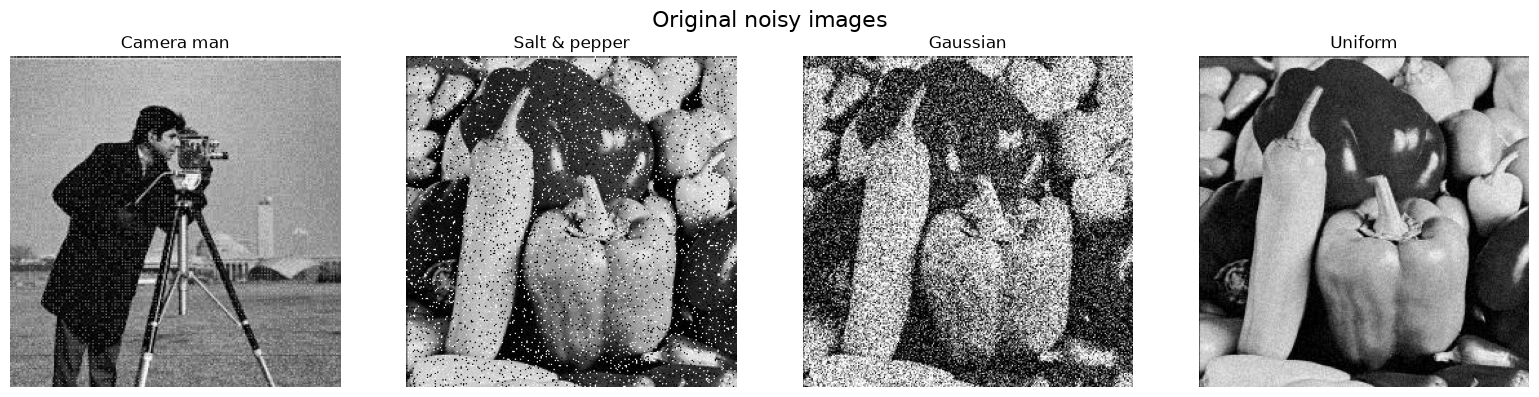

In [5]:
NOISY_IMAGES = {
    "Camera man": "images/camera_man_w_noise.jpg",
    "Salt & pepper": "images/SaltAndPepperNoise.jpg",
    "Gaussian": "images/GaussianNoise.jpg",
    "Uniform": "images/UniformNoise.jpg",
}
noisy_images = {name: ImageReader(path).images[0] for name, path in NOISY_IMAGES.items()}


def show_image_row(images, title):
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    for axis, (label, image) in zip(axes, images.items()):
        axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axis.set_title(label)
        axis.axis("off")
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


show_image_row(noisy_images, "Original noisy images")


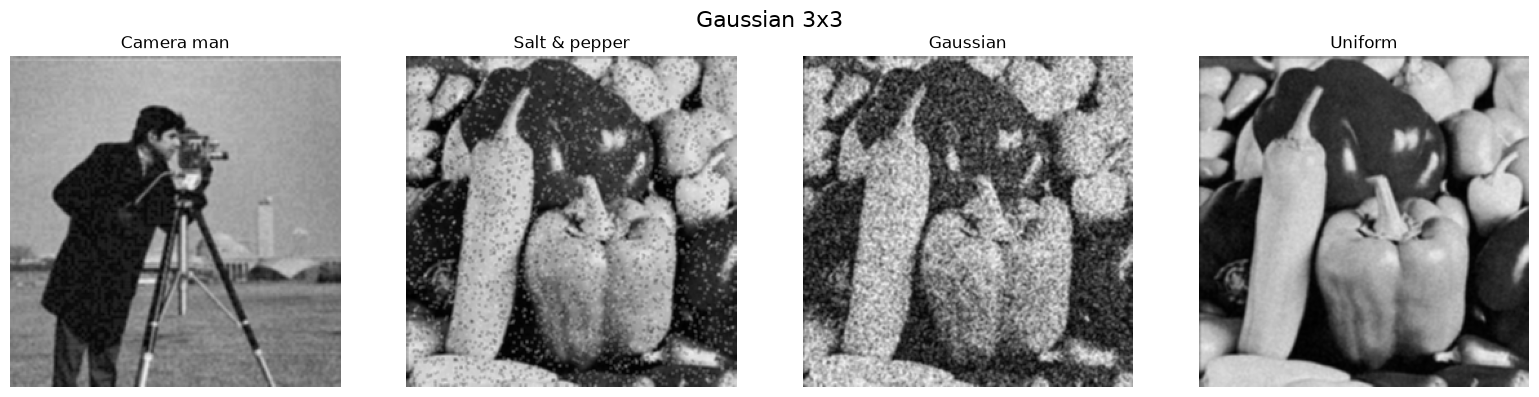

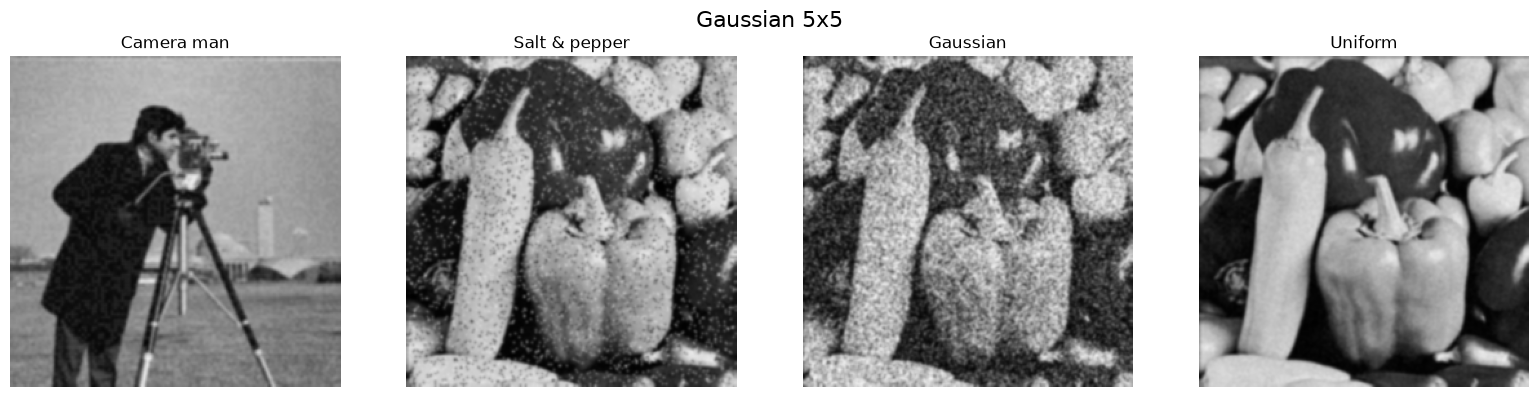

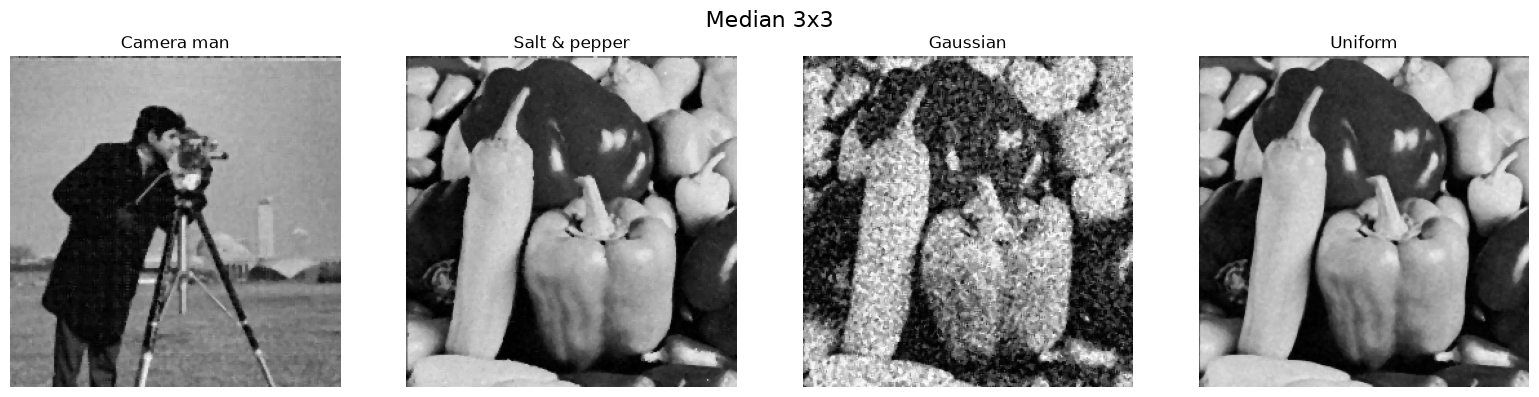

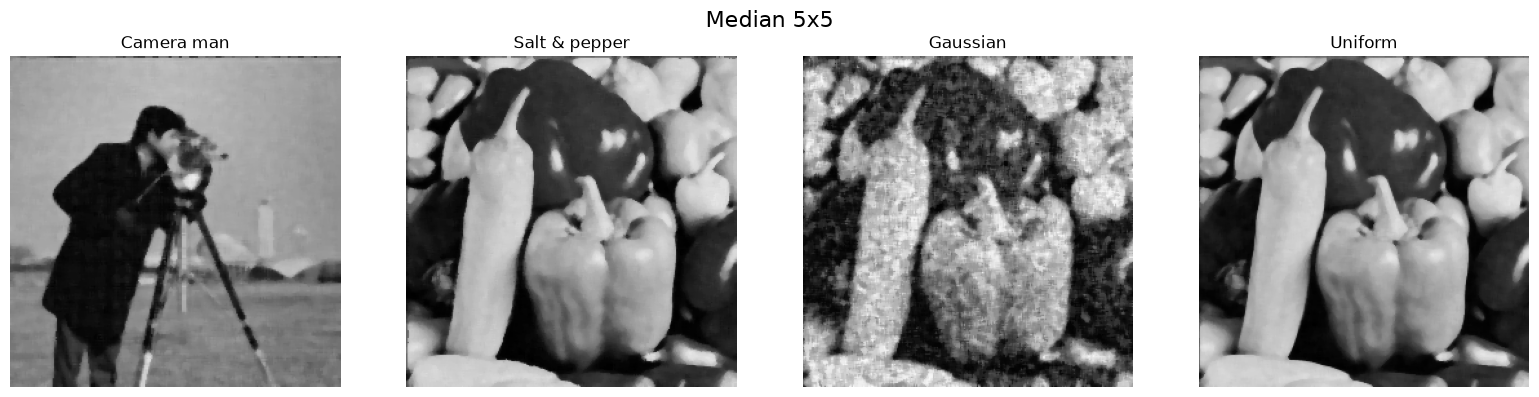

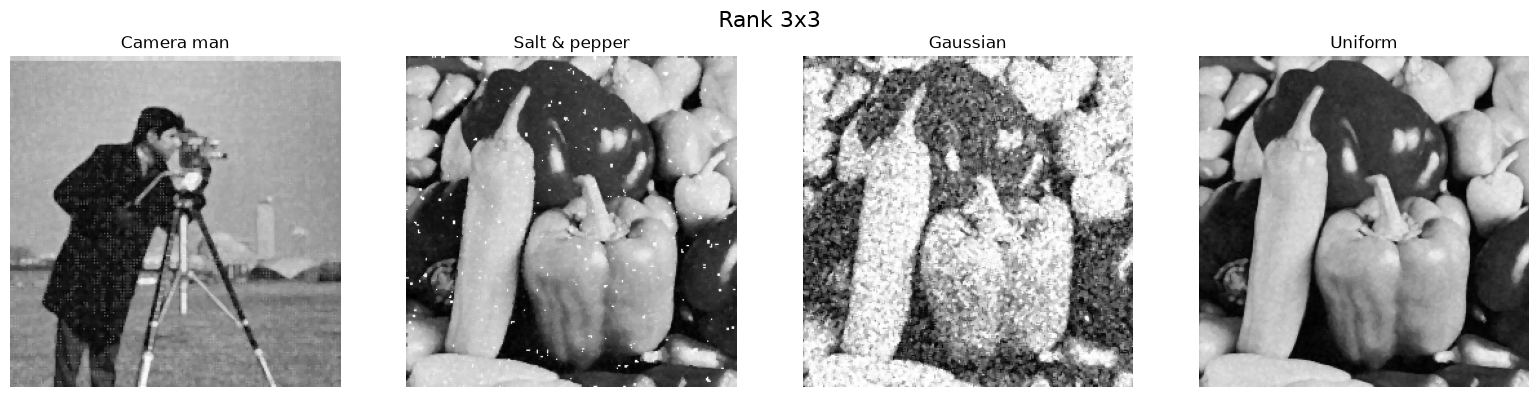

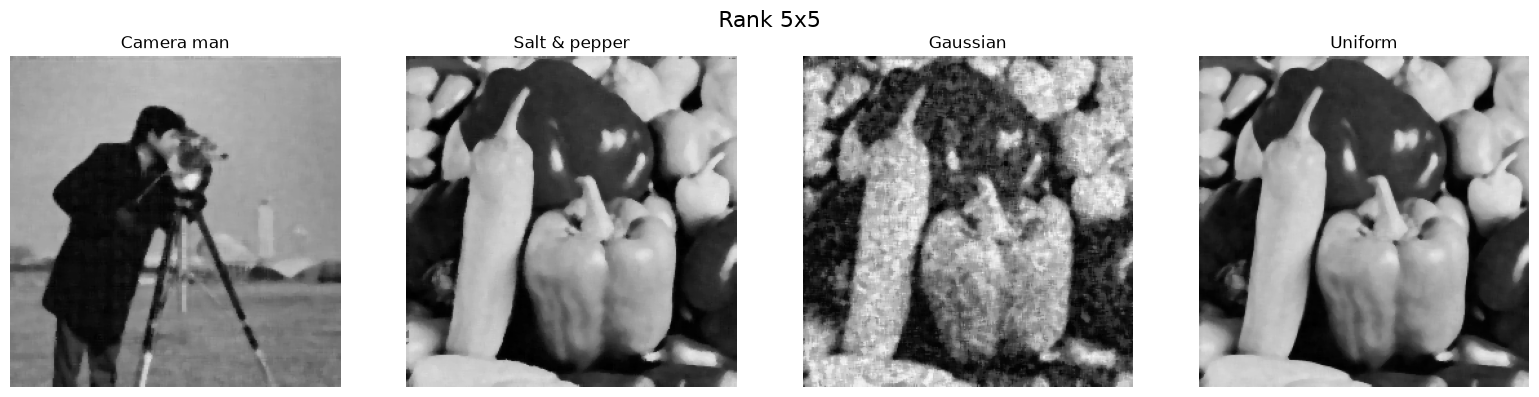

In [6]:
FILTERS = {
    "Gaussian 3x3": {"filter_type": "gaussian", "kernel_size": (3, 3)},
    "Gaussian 5x5": {"filter_type": "gaussian", "kernel_size": (5, 5)},
    "Median 3x3": {"filter_type": "median", "kernel_size": (3, 3)},
    "Median 5x5": {"filter_type": "median", "kernel_size": (5, 5)},
    "Rank 3x3": {"filter_type": "rank", "kernel_size": (3, 3), "rank": 6},
    "Rank 5x5": {"filter_type": "rank", "kernel_size": (5, 5), "rank": 12},
}

filtered_results = {
    label: {name: ImageFiltering(**settings).apply(image) for name, image in noisy_images.items()}
    for label, settings in FILTERS.items()
}

for label, images in filtered_results.items():
    show_image_row(images, label)


<b>4.</b> Use the thresholding tutorial provided on 
https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html. Perform both simple and 
adaptive thresholding. Compare both methods and discuss the tradeoffs between them. Make sure 
to include multiple images demonstrating the findings discussed in the writeup. 

- Coins1 
- Coins2 
- screws

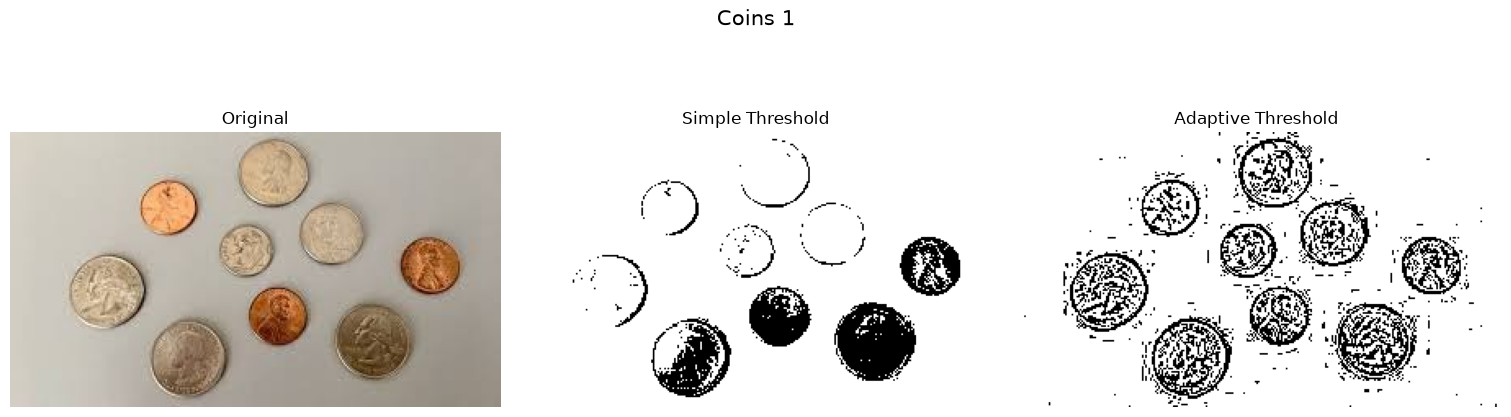

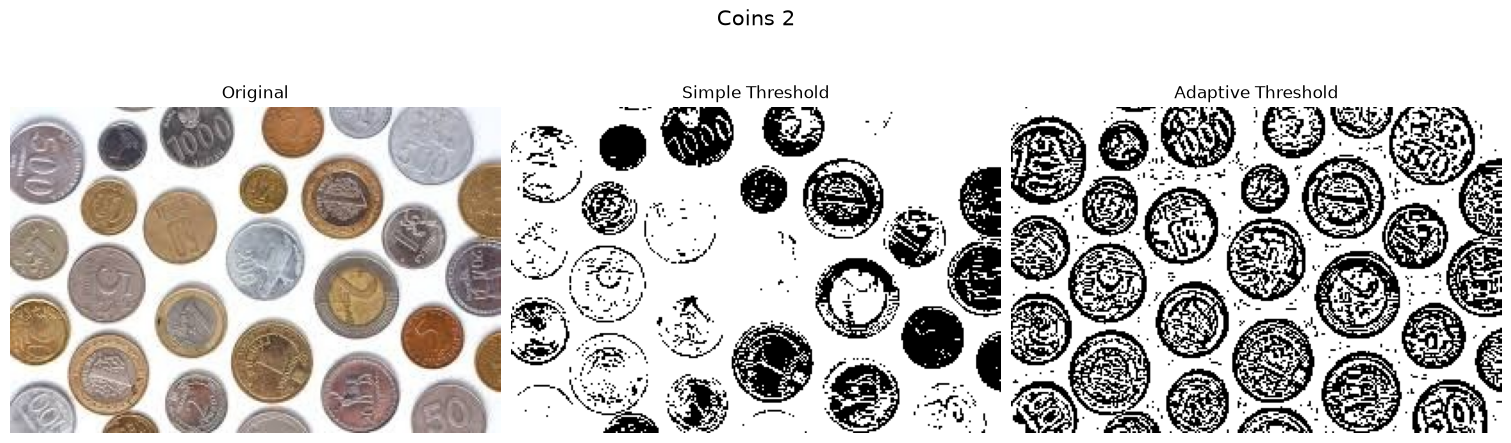

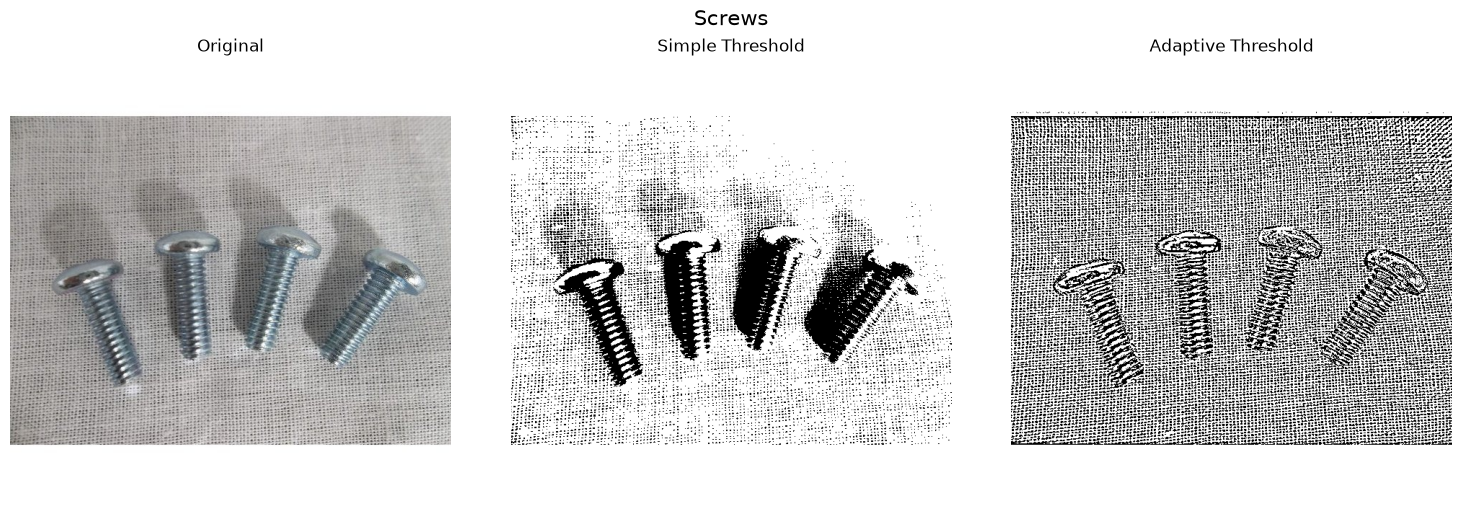

In [7]:
THRESHOLD_IMAGES = {
    "Coins 1": "images/coins1.jpg",
    "Coins 2": "images/coins2.jpg",
    "Screws": "images/screws.jpeg",
}

threshold_sources = {
    name: ImageReader(path).images[0]
    for name, path in THRESHOLD_IMAGES.items()
}


def compare_thresholds(name, image):
    simple = Thresholder(image, "simple").run_thresholding()
    adaptive = Thresholder(image, "adaptive").run_thresholding()

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 5),
        constrained_layout=True
    )

    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")

    axes[1].imshow(simple, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title("Simple Threshold")

    axes[2].imshow(adaptive, cmap="gray", vmin=0, vmax=255)
    axes[2].set_title("Adaptive Threshold")

    for axis in axes:
        axis.axis("off")

    fig.suptitle(name, fontsize=15)
    plt.show()

    return {
        "Original": image,
        "Simple": simple,
        "Adaptive": adaptive,
    }


threshold_results = {
    name: compare_thresholds(name, image)
    for name, image in threshold_sources.items()
}

<b>5.</b> Use morphological operators to improve the segmentation of the images in problem 3. There are 
multiple operations with different masks and orders. Describe which set of operations works best 
and why. Make sure to include all images generated. See 
https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html for help on how to use 
the operators.

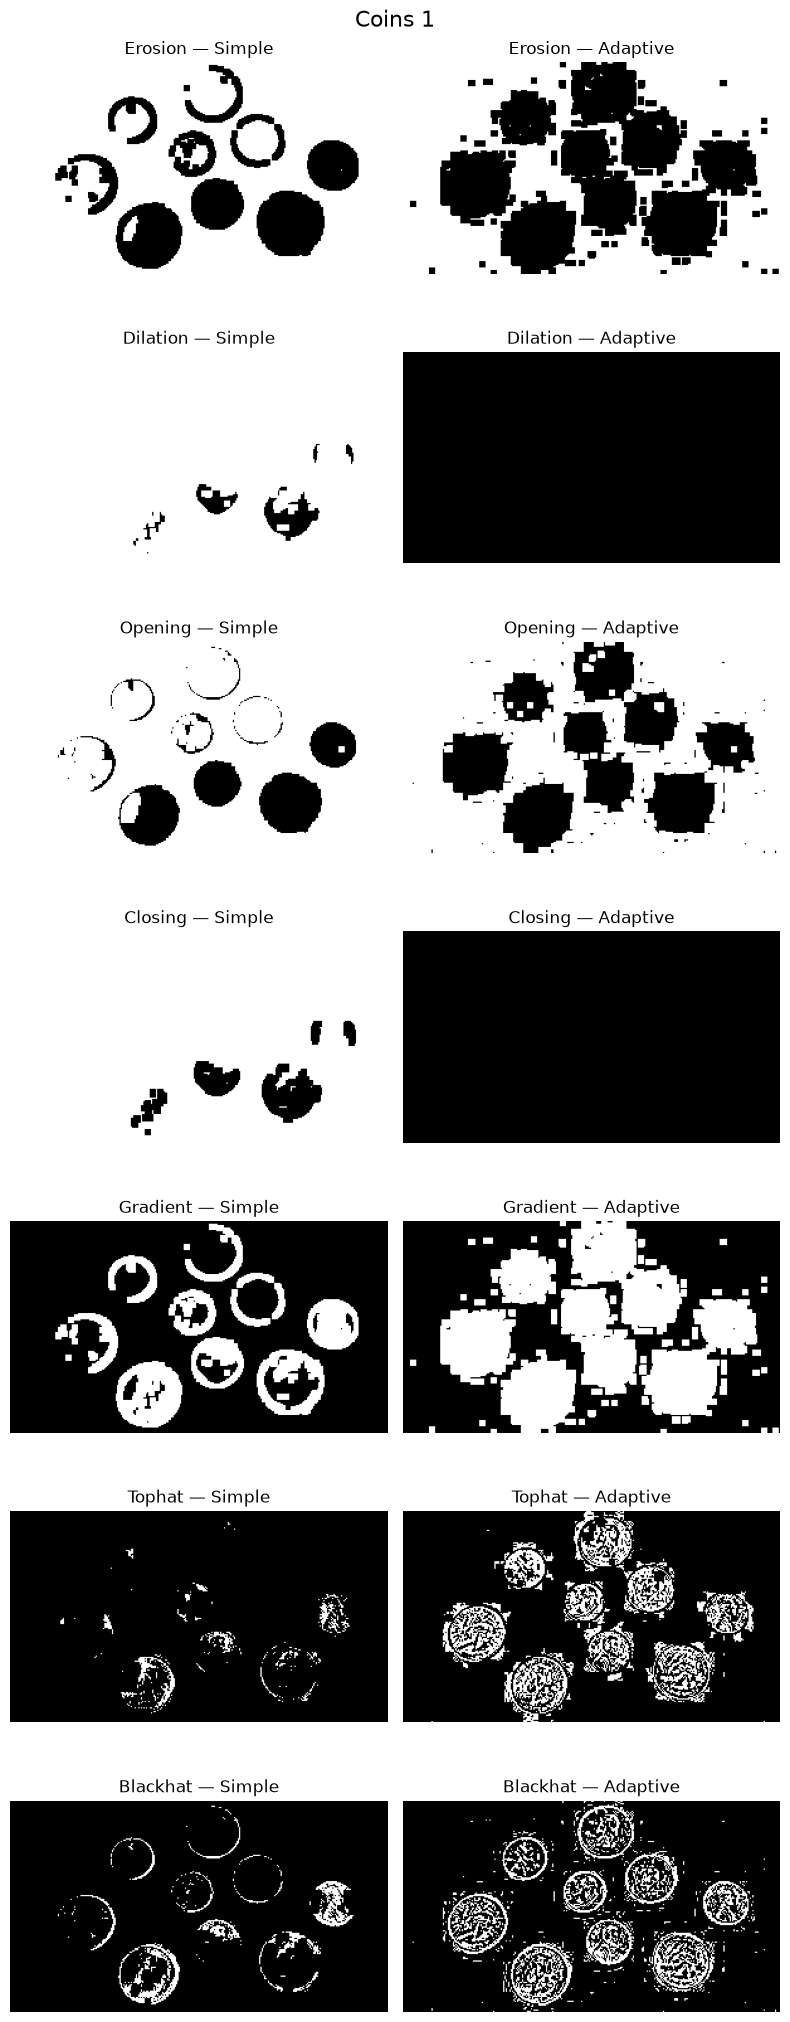

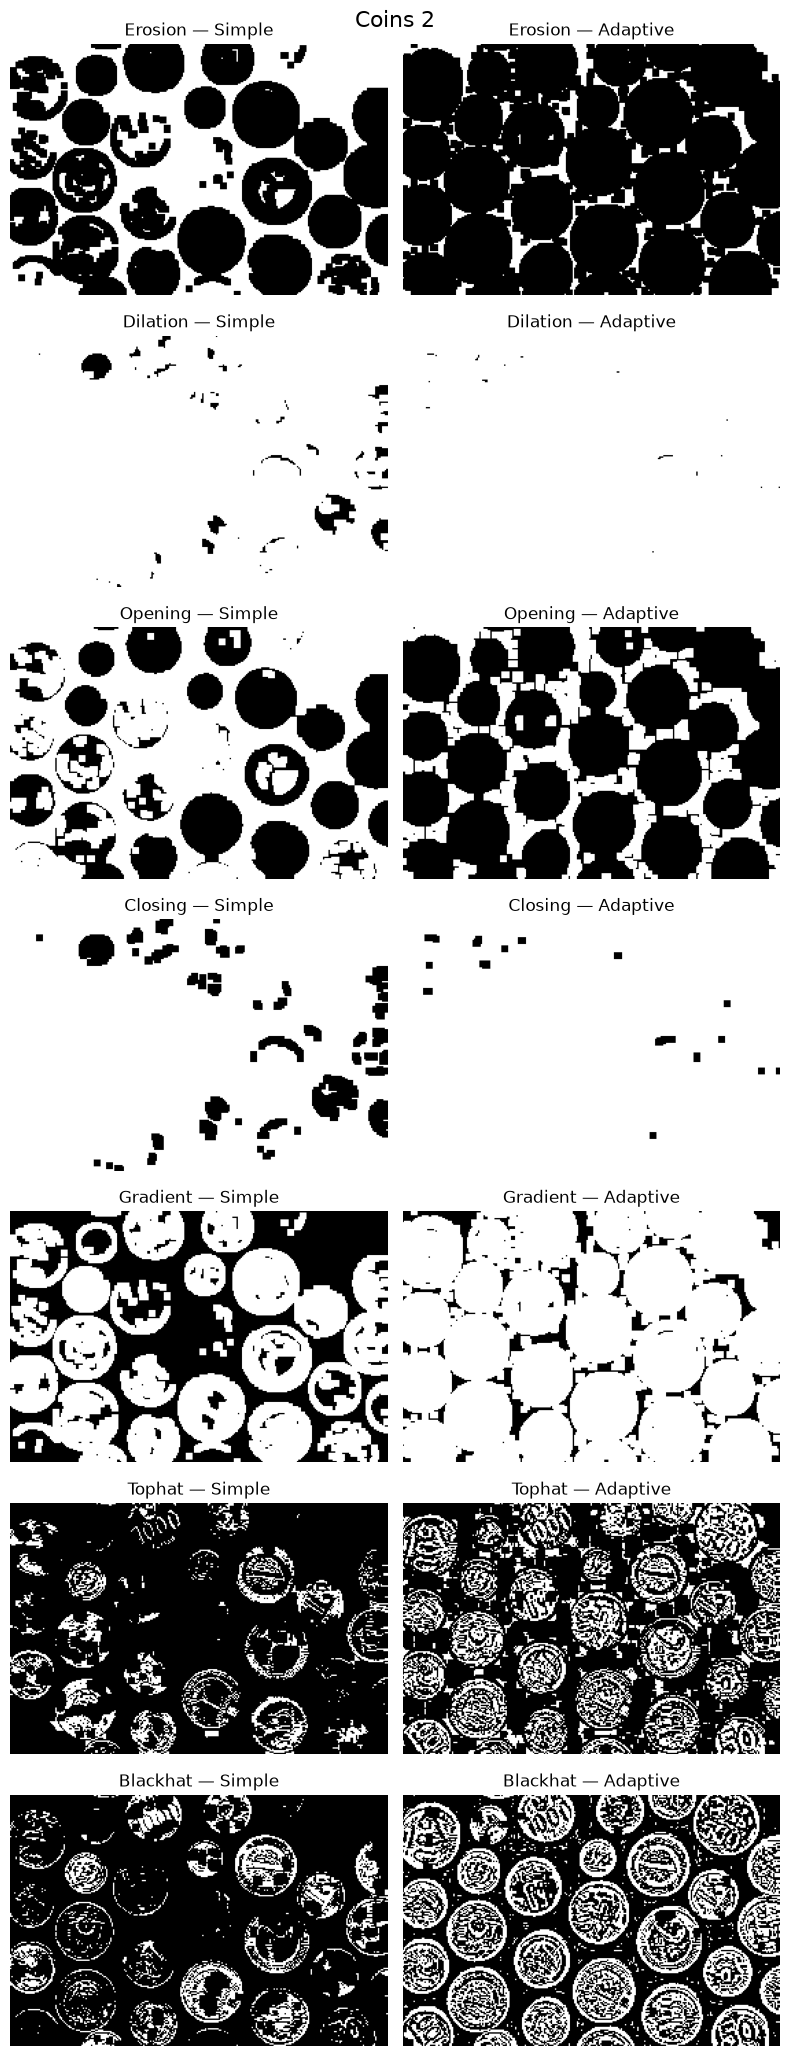

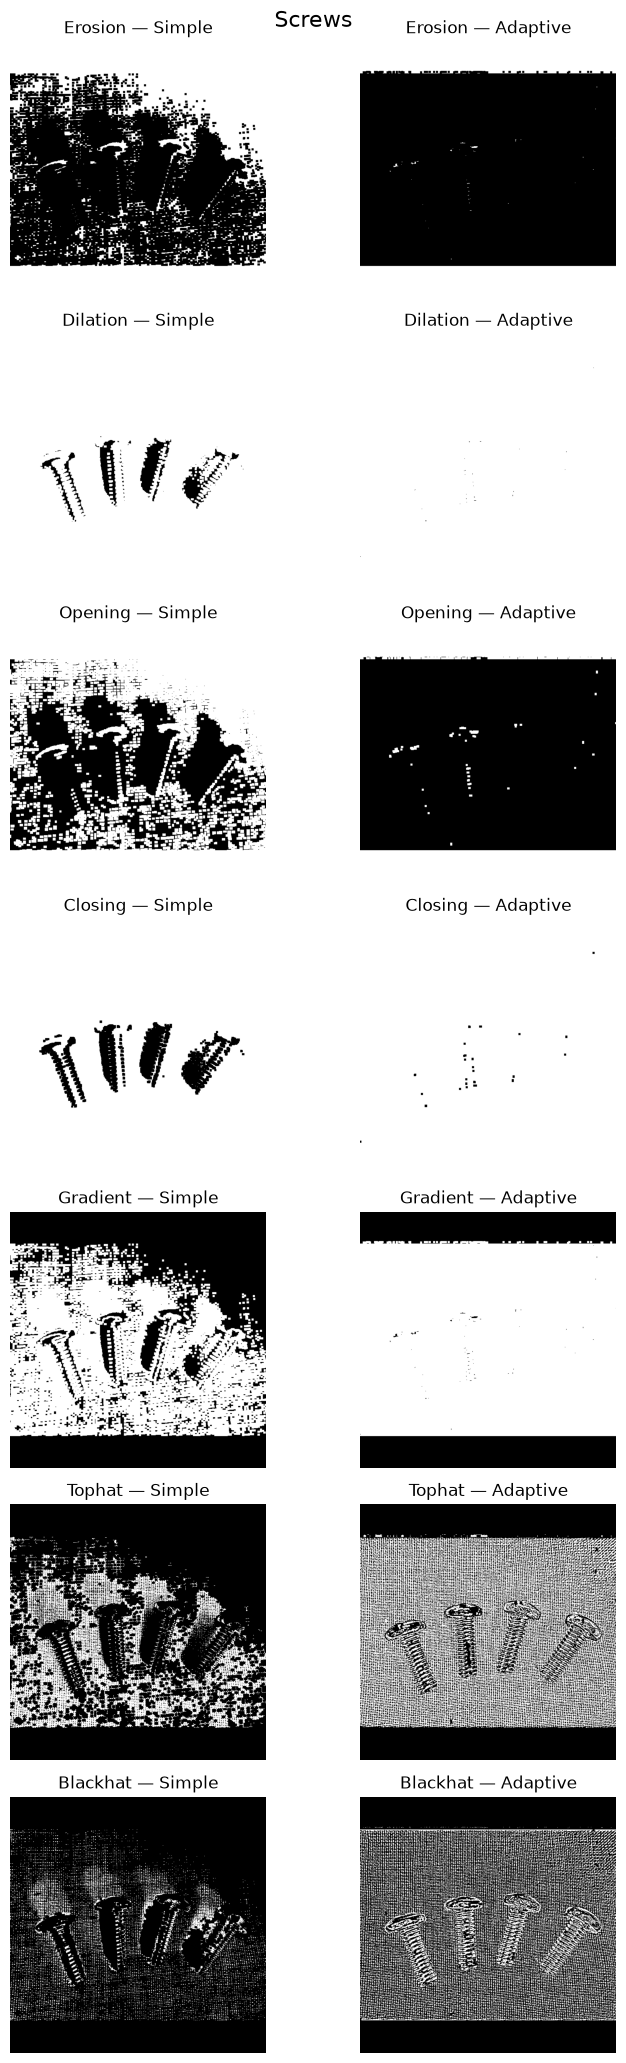

In [8]:
MORPHOLOGY = ["erosion", "dilation", "opening", "closing", "gradient", "tophat", "blackhat"]
morph_filters = {operation: MorphologicalFilter(operation, kernel_size=5) for operation in MORPHOLOGY}


def show_morphology(dataset_name, thresholds):
    inputs = {name: image for name, image in thresholds.items() if name != "Original"}
    fig, axes = plt.subplots(len(morph_filters), len(inputs), figsize=(8, 3 * len(morph_filters)))
    for row, (operation, morph_filter) in enumerate(morph_filters.items()):
        for col, (threshold_name, image) in enumerate(inputs.items()):
            axes[row, col].imshow(morph_filter.apply(image), cmap="gray")
            axes[row, col].set_title(f"{operation.title()} — {threshold_name}")
            axes[row, col].axis("off")
    fig.suptitle(dataset_name, fontsize=16)
    plt.tight_layout()
    plt.show()


for name, thresholds in threshold_results.items():
    show_morphology(name, thresholds)
